In [8]:
!pip install numpy pandas scikit-learn matplotlib

#LAB 10 TASKS

#Task 1:
Imagine you're a data scientist working for a real estate company. Your task is to build a
model to predict house prices based on various features such as the number of
bedrooms, square footage, and the location of the house. You have access to a dataset
with information about houses, including their square footage, number of bedrooms,
number of bathrooms, age of the house, and location (neighborhood). The goal is to
predict the price of the house, which is a continuous variable. Perform the following
task:

- Clean the dataset and handle any missing values. Encode categorical variables
(e.g., neighborhood) as numeric values.

- Identify the relevant features that most likely impact the price.

- Evaluate the performance of the model using any metrics.

- Predict the price of a house given a new set of features.

In [20]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

np.random.seed(42)
n = 200

neighborhoods = np.random.choice(['Downtown', 'Suburbs', 'Uptown', 'Rural'], n)
sqft = np.random.randint(800, 4000, n)
bedrooms = np.random.randint(1, 6, n)
bathrooms = np.random.randint(1, 4, n)
age = np.random.randint(0, 50, n)
sqft = sqft.astype(float)
sqft[np.random.choice(n, 10, replace=False)] = np.nan
age = age.astype(float)
age[np.random.choice(n, 5, replace=False)] = np.nan

df = pd.DataFrame({
    'sqft': sqft,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age': age,
    'neighborhood': neighborhoods
})

df['sqft'] = df['sqft'].fillna(df['sqft'].median())
df['age'] = df['age'].fillna(df['age'].median())

price = ( df['sqft'] * 150 + df['bedrooms'] * 8000 + df['bathrooms'] * 5000 - df['age']
         * 300  + np.where(df['neighborhood'] == 'Downtown', 50000, np.where(df['neighborhood'] == 'Uptown',
          30000, np.where(df['neighborhood'] == 'Suburbs', 10000, 0))) + np.random.randint(-10000, 10000, n)
)
df['price'] = price

le = LabelEncoder()
df['neighborhood_encoded'] = le.fit_transform(df['neighborhood'])
features = ['sqft', 'bedrooms', 'bathrooms', 'age', 'neighborhood_encoded']
X = df[features]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #train test splti

model=LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("House Price Prediction:")
print(f"R2 Score:{r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")

new_house = pd.DataFrame([{
    'sqft': 2000,
    'bedrooms': 3,
    'bathrooms': 2,
    'age': 10,
    'neighborhood_encoded': le.transform(['Suburbs'])[0]
}])
predicted_price = model.predict(new_house)[0]
print(f"new house predicted price:{predicted_price:,.2f}")

House Price Prediction:
R2 Score:0.9697
RMSE: 22,324.71
new house predicted price:351,358.05


#Task 2

You work as a data scientist for an email service provider. Your task is to develop a
model that can classify emails as spam or not spam based on their content. You have a
labeled dataset with thousands of emails. Each email has features such as frequency of
specific words, length of the email, presence of hyperlinks, and sender's address. The
task is to classify an email as spam (1) or not spam (0).
- Preprocess the dataset by converting text features to numerical features.
- Train a model to classify the emails based on their features.
- Evaluate the model&#39;s performance.
- Deploy the model to classify new incoming emails.

In [21]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(0)
n = 500
word_freq_free  = np.random.rand(n)
word_freq_click = np.random.rand(n)
email_length    = np.random.randint(50, 1000, n)
has_hyperlink   = np.random.randint(0, 2, n)
sender_known    = np.random.randint(0, 2, n)

spam_score = ( 2.5 * word_freq_free + 2.0 * word_freq_click + 1.5 * has_hyperlink - 1.5 * sender_known + np.random.randn(n) * 0.5 )
label = (spam_score > 1.5).astype(int)

df = pd.DataFrame({
    'word_freq_free':  word_freq_free,
    'word_freq_click': word_freq_click,
    'email_length':    email_length,
    'has_hyperlink':   has_hyperlink,
    'sender_known':    sender_known,
    'spam':            label
})
X = df.drop('spam', axis=1)
y = df['spam']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred, target_names=['not spam', 'spam']))
print("confusion matrix:")
print(confusion_matrix(y_test, y_pred))

new_email = pd.DataFrame([{
    'word_freq_free':  0.9,
    'word_freq_click': 0.8,
    'email_length':    200,
    'has_hyperlink':   1,
    'sender_known':    0
}])
result = model.predict(new_email)[0]
print(f"new email: {'SPAM' if result == 1 else 'NOT SPAM'}")

Accuracy: 0.9100
classification report:
              precision    recall  f1-score   support

    not spam       0.91      0.83      0.87        36
        spam       0.91      0.95      0.93        64

    accuracy                           0.91       100
   macro avg       0.91      0.89      0.90       100
weighted avg       0.91      0.91      0.91       100

confusion matrix:
[[30  6]
 [ 3 61]]
new email: SPAM


#Task 3
You work for a retail business and your task is to classify customers into two categories:
high-value and low-value customers. The classification is based on customer features
such as total spending in the last 6 months, age, number of visits, and purchase
frequency. You have a dataset with customer information, including spending habits,
frequency of visits, and demographics. The goal is to classify customers into high-value
(1) and low-value (0) categories.
- Clean the dataset and handle any missing or outlier values. Perform feature
scaling if necessary.
- Divide the dataset into a training set and a testing set.
- Find a separating hyperplane for classification.
- Find rules that classify customers based on their features.
- Evaluate the performance of the model.

In [22]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(7)
n = 400
total_spending    = np.random.uniform(100, 5000, n)
age               = np.random.randint(18, 70, n)
num_visits        = np.random.randint(1, 50, n)
purchase_freq     = np.random.uniform(0.1, 10, n)

label = ((total_spending > 2500) & (num_visits > 20)).astype(int)
df = pd.DataFrame({
    'total_spending':  total_spending,
    'age':             age,
    'num_visits':      num_visits,
    'purchase_freq':   purchase_freq,
    'customer_value':  label
})

for col in ['total_spending', 'num_visits', 'purchase_freq']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    df[col] = df[col].clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)

X = df.drop('customer_value', axis=1)
y = df['customer_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train_scaled, y_train)
y_pred_svm = svm.predict(X_test_scaled)
print(f"accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Low-Value', 'High-Value']))

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"decision tree accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(classification_report(y_test, y_pred_dt, target_names=['Low-Value', 'High-Value']))

new_customer = pd.DataFrame([{
    'total_spending': 3200,
    'age': 35,
    'num_visits': 30,
    'purchase_freq': 7.5
}])
new_scaled = scaler.transform(new_customer)
svm_result = svm.predict(new_scaled)[0]
dt_result  = dt.predict(new_customer)[0]

label_map = {0: 'LOW-VALUE', 1: 'HIGH-VALUE'}
print(f"New customer: {label_map[svm_result]}, Decision Tree: {label_map[dt_result]}")

accuracy: 0.9625
              precision    recall  f1-score   support

   Low-Value       0.97      0.98      0.98        65
  High-Value       0.93      0.87      0.90        15

    accuracy                           0.96        80
   macro avg       0.95      0.93      0.94        80
weighted avg       0.96      0.96      0.96        80

decision tree accuracy: 0.9875
              precision    recall  f1-score   support

   Low-Value       0.98      1.00      0.99        65
  High-Value       1.00      0.93      0.97        15

    accuracy                           0.99        80
   macro avg       0.99      0.97      0.98        80
weighted avg       0.99      0.99      0.99        80

New customer: HIGH-VALUE, Decision Tree: HIGH-VALUE


#LAB 11 TASKS

#Task 1
In the example code above, customer segmentation was performed using only two features. Now, use all available features except customer_id to implement K-Means
clustering. Perform the clustering twice — once without feature scaling, and once with
scaling applied to all features except age. Compare the results and comment on the
differences and insights observed from these changes.

In [9]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


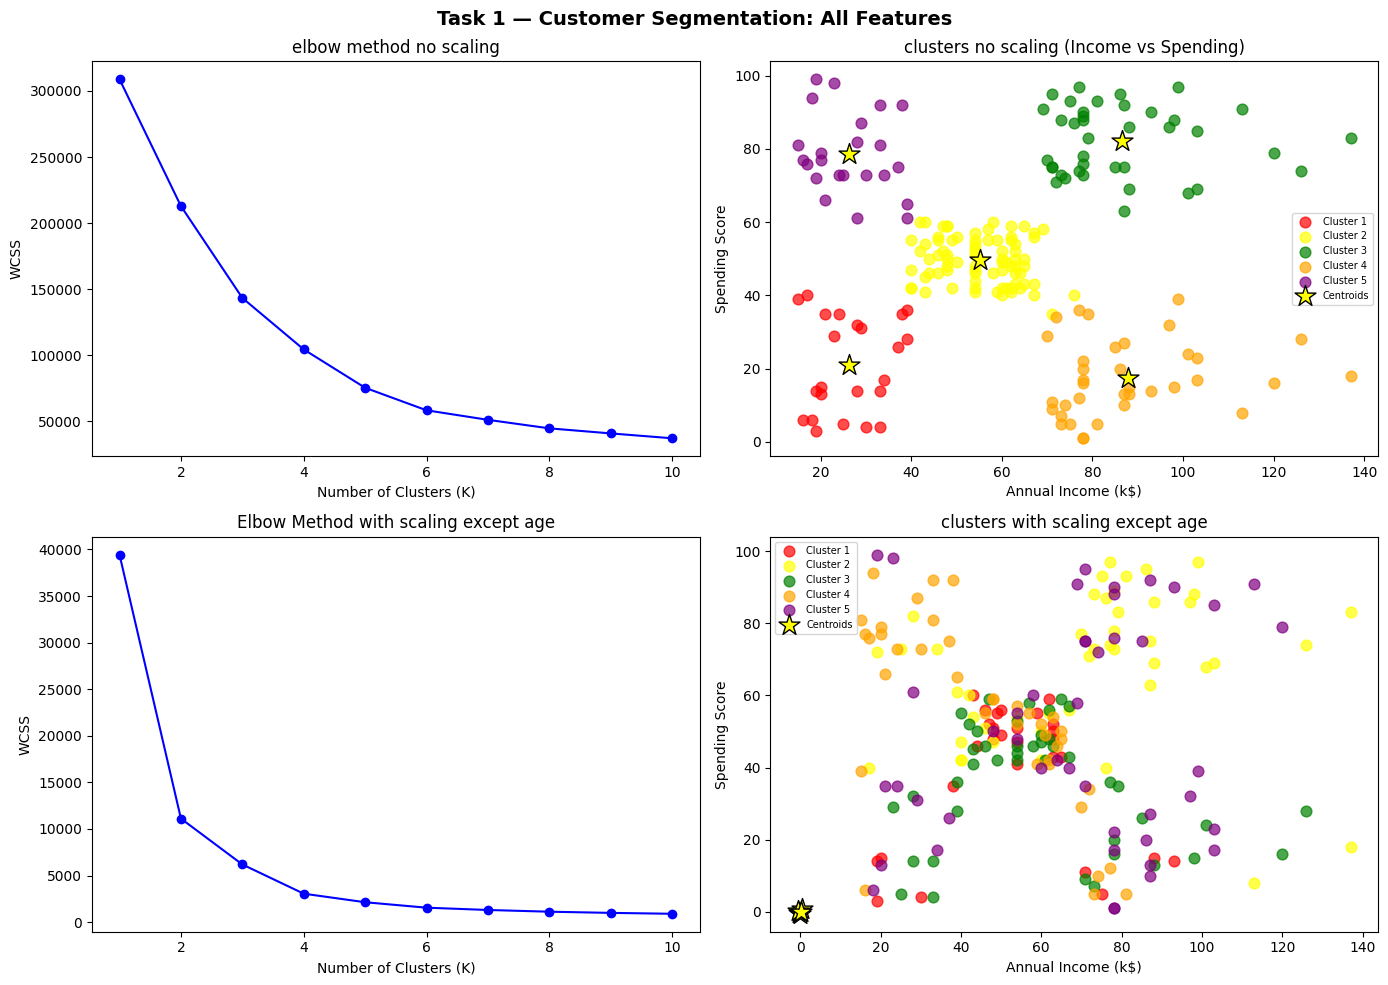

Without scaling — cluster sizes: [23 79 39 36 23]
With scaling    — cluster sizes: [28 46 43 38 45]
qithout scaling, Annual_Income (range 15-140) dominates the distance calculation and overshadows Gender and Spending_Score
With scaling applied to all features except Age, each feature contributes more equally, producing more balanced and meaningful clusters.
The elbow curve shifts because WCSS values are now based on normalised distances, so the y-axis scale changes significantly


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('Mall_Customers.csv')
le = LabelEncoder()
df['Genre_encoded'] = le.fit_transform(df['Genre'])

features = ['Genre_encoded', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

wcss_no_scale = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    wcss_no_scale.append(km.inertia_)

km_no_scale = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels_no_scale = km_no_scale.fit_predict(X)

# PART B — Clustering with scaling (all features excepy age)
X_scaled = X.copy().astype(float)
scaler = StandardScaler()
X_scaled[:, features_to_scale_indices] = scaler.fit_transform(X[:, features_to_scale_indices])

wcss_scaled = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss_scaled.append(km.inertia_)

km_scaled = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 1 — Customer Segmentation: All Features', fontsize=14, fontweight='bold')

colors = ['red', 'yellow', 'green', 'orange', 'purple']

axes[0, 0].plot(range(1, 11), wcss_no_scale, marker='o', color='blue')
axes[0, 0].set_title('elbow method no scaling')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('WCSS')

for i in range(5):
    mask = labels_no_scale == i
    axes[0, 1].scatter(X[mask, 2], X[mask, 3], s=60, c=colors[i], label=f'Cluster {i+1}', alpha=0.7)
axes[0, 1].scatter(km_no_scale.cluster_centers_[:, 2], km_no_scale.cluster_centers_[:, 3], s=250, c='yellow', marker='*', edgecolors='black', label='Centroids')
axes[0, 1].set_title('clusters no scaling (Income vs Spending)')
axes[0, 1].set_xlabel('Annual Income (k$)')
axes[0, 1].set_ylabel('Spending Score')
axes[0, 1].legend(fontsize=7)

axes[1, 0].plot(range(1, 11), wcss_scaled, marker='o', color='blue')
axes[1, 0].set_title('Elbow Method with scaling except age')
axes[1, 0].set_xlabel('Number of Clusters (K)')
axes[1, 0].set_ylabel('WCSS')

for i in range(5):
    mask = labels_scaled == i
    axes[1, 1].scatter(X[mask, 2], X[mask, 3], s=60, c=colors[i], label=f'Cluster {i+1}', alpha=0.7)
axes[1, 1].scatter(km_scaled.cluster_centers_[:, 2], km_scaled.cluster_centers_[:, 3], s=250, c='yellow', marker='*', edgecolors='black', label='Centroids')
axes[1, 1].set_title('clusters with scaling except age')
axes[1, 1].set_xlabel('Annual Income (k$)')
axes[1, 1].set_ylabel('Spending Score')
axes[1, 1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('task1_customer_segmentation.png', dpi=150)
plt.show()
print(f"Without scaling — cluster sizes: {np.bincount(labels_no_scale)}")
print(f"With scaling — cluster sizes: {np.bincount(labels_scaled)}")
print("qithout scaling, Annual_Income (range 15-140) dominates the distance calculation and overshadows Gender and Spending_Score")
print("With scaling applied to all features except Age, each feature contributes more equally, producing more balanced and meaningful clusters.")
print("The elbow curve shifts because WCSS values are now based on normalised distances, so the y-axis scale changes significantly")

#Task 2
A transportation company wants to optimize its routes and fleet by categorizing
different types of vehicles based on their usage patterns. The company has data on
several features such as: vehicle_serial_no, mileage, fuel_efficiency, maintenance_cost,
and vehicle_type. The goal is to create segments of vehicles based on these attributes to
help with fleet management. Implement K-Means clustering to group vehicles using all
the features. Perform the clustering twice: once without scaling the features and once
with scaling applied to all features (except for vehicle_type, which is categorical).
Analyze and compare the results, focusing on how the scaling affects the clustering
output.
Sample Data:
# Example vehicle data
data = {

‘vehicle_serial_no’: [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
&#39;mileage&#39;: [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000,
75000, 280000],

&#39;fuel_efficiency&#39;: [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
&#39;maintenance_cost&#39;: [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],

&#39;vehicle_type&#39;: [&#39;SUV&#39;, &#39;Sedan&#39;, &#39;Truck&#39;, &#39;Hatchback&#39;, &#39;Sedan&#39;, &#39;Truck&#39;, &#39;SUV&#39;, &#39;Truck&#39;,

&#39;Hatchback&#39;, &#39;SUV&#39;]

}
# Create a DataFrame
df = pd.DataFrame(data)

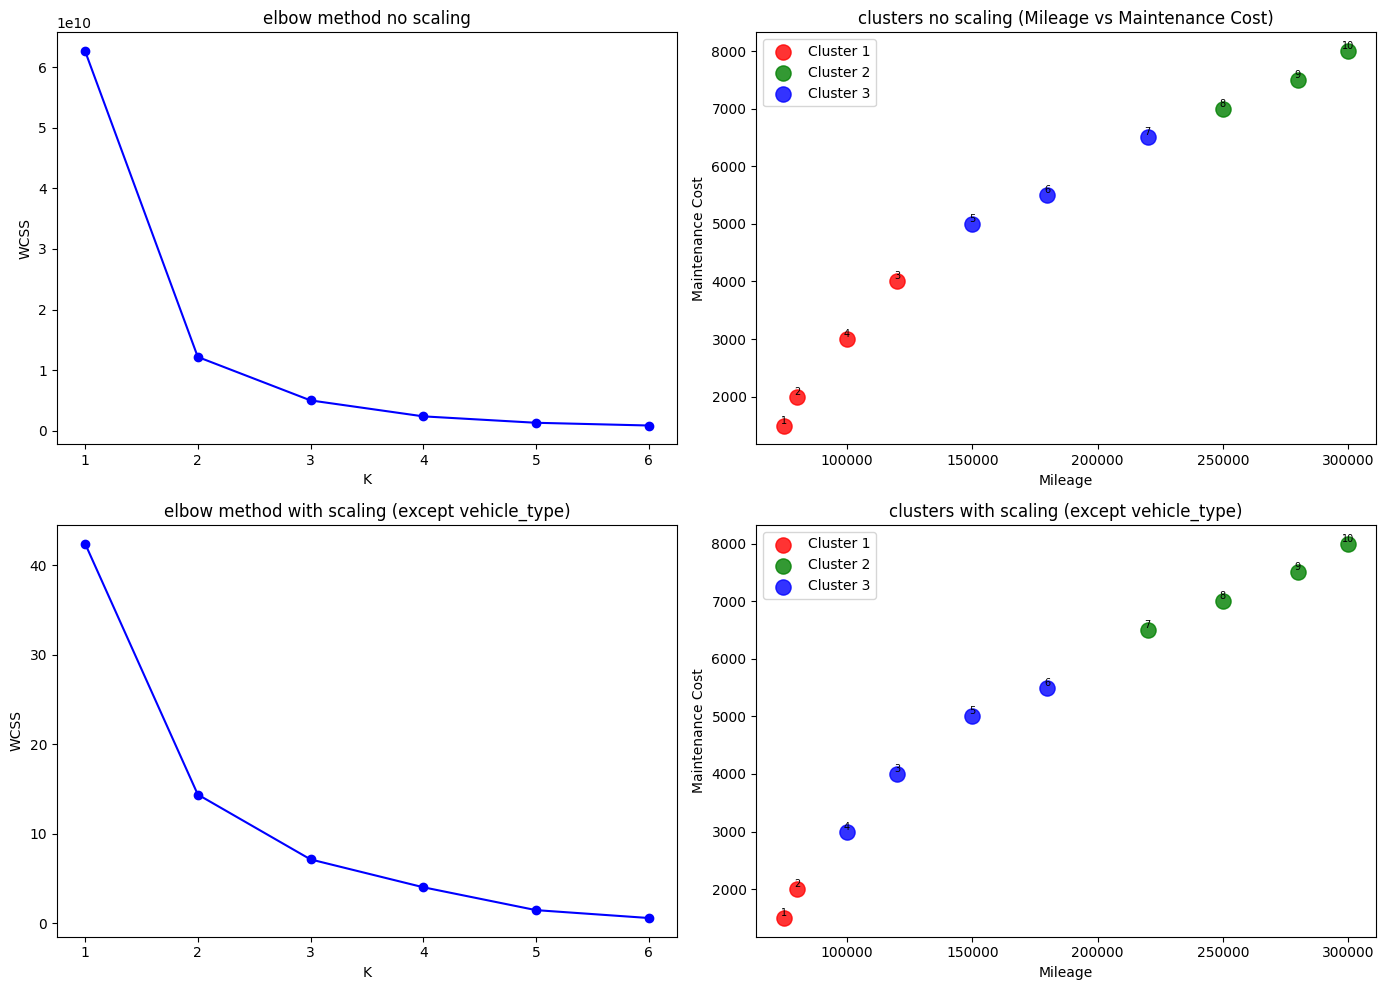

 vehicle_serial_no vehicle_type  mileage  fuel_efficiency  maintenance_cost  Cluster_NoScale  Cluster_Scaled
                 5          SUV   150000               15              5000                2               2
                 3        Sedan   120000               18              4000                0               2
                 8        Truck   250000               10              7000                1               1
                 2    Hatchback    80000               22              2000                0               0
                 4        Sedan   100000               20              3000                0               2
                 7        Truck   220000               12              6500                2               1
                 6          SUV   180000               16              5500                2               2
                10        Truck   300000                8              8000                1               1
                 1 

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage':           [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency':   [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost':  [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type':      ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df = pd.DataFrame(data)

le = LabelEncoder()
df['vehicle_type_encoded'] = le.fit_transform(df['vehicle_type'])

numeric_features = ['mileage', 'fuel_efficiency', 'maintenance_cost', 'vehicle_type_encoded']
X = df[numeric_features].values

K = 3  #small dataset so only 3 clusters

wcss_no_scale = []
for k in range(1, 7):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    wcss_no_scale.append(km.inertia_)

km_no_scale = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
labels_no_scale = km_no_scale.fit_predict(X)

X_scaled = X.copy().astype(float)
scaler = StandardScaler()
X_scaled[:, :3] = scaler.fit_transform(X[:, :3])

wcss_scaled = []
for k in range(1, 7):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss_scaled.append(km.inertia_)

km_scaled = KMeans(n_clusters=K, init='k-means++', random_state=42, n_init=10)
labels_scaled = km_scaled.fit_predict(X_scaled)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['red', 'green', 'blue']

axes[0, 0].plot(range(1, 7), wcss_no_scale, marker='o', color='blue')
axes[0, 0].set_title('elbow method no scaling')
axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('WCSS')

for i in range(K):
    mask = labels_no_scale == i
    axes[0, 1].scatter(X[mask, 0], X[mask, 2], s=120, c=colors[i], label=f'Cluster {i+1}', alpha=0.8)
for idx, row in df.iterrows():
    axes[0, 1].annotate(row['vehicle_serial_no'], (X[idx, 0], X[idx, 2]), fontsize=7, ha='center', va='bottom')
axes[0, 1].set_title('clusters no scaling (Mileage vs Maintenance Cost)')
axes[0, 1].set_xlabel('Mileage')
axes[0, 1].set_ylabel('Maintenance Cost')
axes[0, 1].legend()

axes[1, 0].plot(range(1, 7), wcss_scaled, marker='o', color='blue')
axes[1, 0].set_title('elbow method with scaling (except vehicle_type)')
axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('WCSS')

for i in range(K):
    mask = labels_scaled == i
    axes[1, 1].scatter(X[mask, 0], X[mask, 2], s=120, c=colors[i], label=f'Cluster {i+1}', alpha=0.8)
for idx, row in df.iterrows():
    axes[1, 1].annotate(row['vehicle_serial_no'], (X[idx, 0], X[idx, 2]), fontsize=7, ha='center', va='bottom')
axes[1, 1].set_title('clusters with scaling (except vehicle_type)')
axes[1, 1].set_xlabel('Mileage')
axes[1, 1].set_ylabel('Maintenance Cost')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('task2_vehicle_clustering.png', dpi=150)
plt.show()

# Results table
df['Cluster_NoScale'] = labels_no_scale
df['Cluster_Scaled']  = labels_scaled
print(df[['vehicle_serial_no', 'vehicle_type', 'mileage', 'fuel_efficiency',
          'maintenance_cost', 'Cluster_NoScale', 'Cluster_Scaled']].to_string(index=False))
print("without scaling, mileage (range 75000-300000) and maintenance_cost (1500-8000) completely dominate the clustering — fuel_efficiency (8-24) has almost no effect")
print("With scaling applied to all numeric features except vehicle_type, all three numeric features contribute equally. This produces more meaningful vehicle groups(e.g. high-mileage/high-cost trucks vs low-mileage/efficient hatchbacks)")
print("Scaling is critical here because the feature ranges differ by orders of magnitude.")

#Task 3
The academic affairs department at FAST NUCES Karachi is looking to identify distinct
groups of students based on their academic engagement and performance. The
department has access to anonymized student data containing the attributes student_id,
GPA, study_hours (average weekly study hours), and attendance_rate (percentage of classes attended).

The goal is to group students into meaningful clusters that can help tailor academic
support programs, such as extra tutoring, mentoring sessions, or motivation workshops.

You are required to perform unsupervised learning using K-Means clustering on
the student dataset. Do following :
- Feature Selection and Scaling: Use the following features for clustering: GPA,
study_hours, and attendance_rate.
- Apply appropriate feature scaling before clustering.
- Determine Optimal Number of Clusters (K): Use the ELbow method to determine
the optimal number of clusters (K) in the range of 2 to 6.
- Perform Clustering: Apply K-Means using the optimal K and assign a cluster label
to each student.
- Visualization: Create a scatter plot to visualize the clusters using study_hours
and GPA as the axes.
- Color each point based on its cluster.
- Add an informative title and labels for clarity.
- Deliverables: Display the final dataset showing student IDs along with their
assigned cluster.
- Present the scatter plot that illustrates the clustering result.

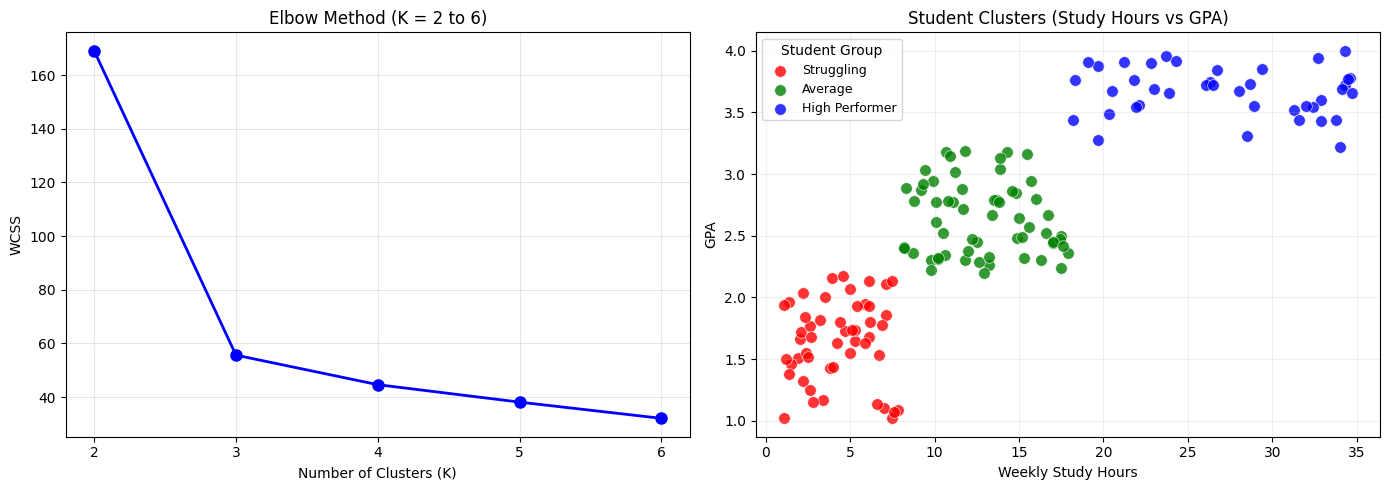

student_id  GPA  study_hours  attendance_rate  cluster          group
      S001 1.66          2.0             62.7        0     Struggling
      S002 1.86          7.1             59.4        0     Struggling
      S003 1.72          2.1             48.3        0     Struggling
      S004 1.65          5.3             42.0        0     Struggling
      S005 1.51          1.9             50.2        0     Struggling
      S006 1.78          6.9             45.8        0     Struggling
      S007 1.53          6.7             43.3        0     Struggling
      S008 2.07          5.0             41.3        0     Struggling
      S009 2.16          3.9             58.1        0     Struggling
      S010 1.46          1.5             40.3        0     Struggling
      S011 1.95          5.9             59.3        0     Struggling
      S012 1.63          4.2             43.7        0     Struggling
      S013 1.68          6.1             42.0        0     Struggling
      S014 2.11     

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(0)
n = 150
student_ids = [f'S{str(i).zfill(3)}' for i in range(1, n+1)]

gpa_vals   = np.concatenate([np.random.uniform(1.0, 2.2, 50), np.random.uniform(2.2, 3.2, 60), np.random.uniform(3.2, 4.0, 40)])
study_hrs  = np.concatenate([np.random.uniform(1, 8, 50), np.random.uniform(8, 18, 60), np.random.uniform(18, 35, 40)])
attend_pct = np.concatenate([np.random.uniform(40, 65, 50), np.random.uniform(65, 85, 60), np.random.uniform(85, 100, 40)])

df = pd.DataFrame({
    'student_id': student_ids,
    'GPA': np.round(gpa_vals, 2),
    'study_hours': np.round(study_hrs, 1),
    'attendance_rate': np.round(attend_pct, 1)
})

features = ['GPA', 'study_hours', 'attendance_rate']
X = df[features].values

scholar = StandardScaler()
X_scaled = scholar.fit_transform(X)

wcss = []
K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, wcss, marker='o', color='blue', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method (K = 2 to 6)')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

optimal_k = 3
km_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_scaled)

cluster_labels = {0: 'Struggling', 1: 'Average', 2: 'High Performer'}

centroids_gpa = [X_scaled[df['cluster'] == i, 0].mean() for i in range(optimal_k)]
order = np.argsort(centroids_gpa)   # lowest GPA centroid → 0 (Struggling)
remap = {order[i]: i for i in range(optimal_k)}
df['cluster'] = df['cluster'].map(remap)
df['group'] = df['cluster'].map(cluster_labels)


colorss = {0: 'red', 1: 'green', 2: 'blue'}
group_colors = df['cluster'].map(colorss)

for cid, cname in cluster_labels.items():
    mask = df['cluster'] == cid
    axes[1].scatter(df.loc[mask, 'study_hours'], df.loc[mask, 'GPA'],
                    c=colorss[cid], s=70, alpha=0.8, label=cname, edgecolors='white', linewidths=0.5)

axes[1].set_title('Student Clusters (Study Hours vs GPA)')
axes[1].set_xlabel('Weekly Study Hours')
axes[1].set_ylabel('GPA')
axes[1].legend(title='Student Group', fontsize=9)
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('task3_student_clustering.png', dpi=150)
plt.show()

print(df[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'cluster', 'group']].to_string(index=False))
summary = df.groupby('group')[features].mean().round(2)
summary.index.name = 'Group'
print(summary)

print(f"""
Optimal K selected: {optimal_k}
Rationale: The elbow curve shows the sharpest bend at K=3, meaning adding a
4th cluster does not meaningfully reduce within-cluster variance.
Groups identified:
  - Struggling : Low GPA, few study hours, poor attendance → needs tutoring
  - Average : Mid GPA, moderate study hours → needs mentoring
  - High Performer : High GPA, high study hours, high attendance → recognition/leadership
""")